In [1]:
import sys
sys.path.append("..")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import json
import os
import math

from src.dataset import load_data, get_dataloaders
from src.models import build_model
from src.train import train
from src.evaluate import evaluate_model, compute_bleu, greedy_decode

# ── Paths ──────────────────────────────────────────────────────
DATA_DIR   = "../data"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Device ─────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:

BATCH_SIZE    = 64
D_MODEL       = 128     # embedding dimension — must be divisible by N_HEADS
N_HEADS       = 4       # number of attention heads
N_ENC_LAYERS  = 2       # encoder layers
N_DEC_LAYERS  = 2       # decoder layers
D_FF          = 256     # feedforward inner dimension
DROPOUT       = 0.1     # transformers need less dropout than LSTMs
N_EPOCHS      = 15
LR            = 3e-4
MAX_LEN       = 30

In [3]:
import random

train_pairs, val_pairs, test_pairs, vocab = load_data(
    train_path=f"{DATA_DIR}/train.csv",
    val_path=f"{DATA_DIR}/validation.csv",
    test_path=f"{DATA_DIR}/test.csv",
    src_col="radiology_report",
    tgt_col="layman_report",
    max_len=MAX_LEN,
    min_freq=2,
)

# Same subsample as NB2 — fair comparison
random.seed(42)
train_pairs = random.sample(train_pairs, 5000)
val_pairs   = random.sample(val_pairs,   500)

train_loader, val_loader, test_loader = get_dataloaders(
    train_pairs, val_pairs, test_pairs,
    vocab=vocab,
    batch_size=BATCH_SIZE,
)

print(f"Vocabulary size : {len(vocab)}")
print(f"Train pairs     : {len(train_pairs)}")
print(f"Val pairs       : {len(val_pairs)}")
print(f"Test pairs      : {len(test_pairs)}")

Train: 71508 | Val: 5037 | Test: 4629
Vocabulary built: 5422 words
Vocabulary size : 5422
Train pairs     : 5000
Val pairs       : 500
Test pairs      : 4629


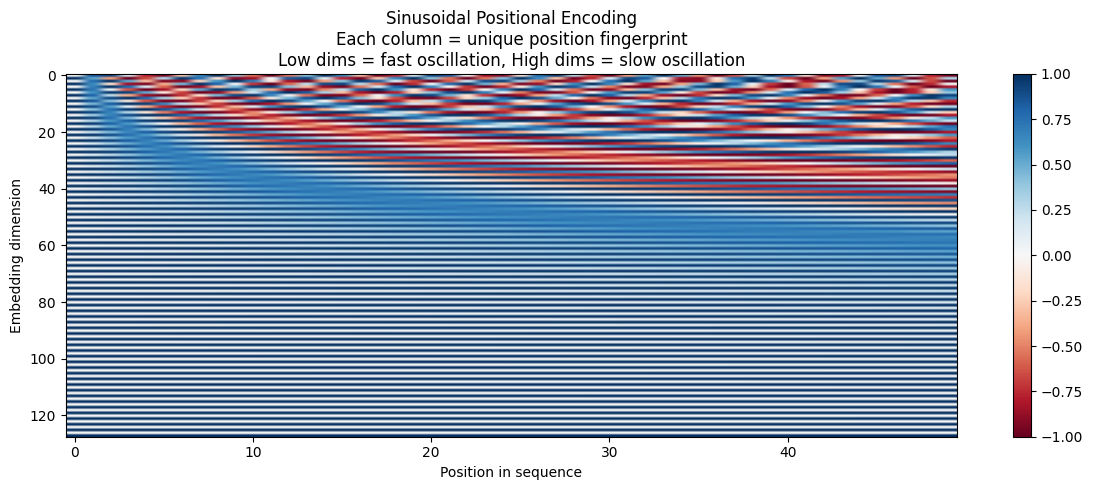

In [4]:
def visualize_positional_encoding(d_model=128, max_len=50):
    """
    Visualize sinusoidal positional encodings.
    Each row = one position. Each column = one embedding dimension.
    Pattern shows how each position gets a unique signature.
    """
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len).unsqueeze(1).float()
    div_term = torch.exp(
        torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    plt.figure(figsize=(12, 5))
    plt.imshow(pe.numpy().T, cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xlabel("Position in sequence")
    plt.ylabel("Embedding dimension")
    plt.title("Sinusoidal Positional Encoding\n"
               "Each column = unique position fingerprint\n"
               "Low dims = fast oscillation, High dims = slow oscillation")
    plt.tight_layout()
    plt.savefig(f"{MODELS_DIR}/positional_encoding.png", dpi=150)
    plt.show()

visualize_positional_encoding(D_MODEL, max_len=50)

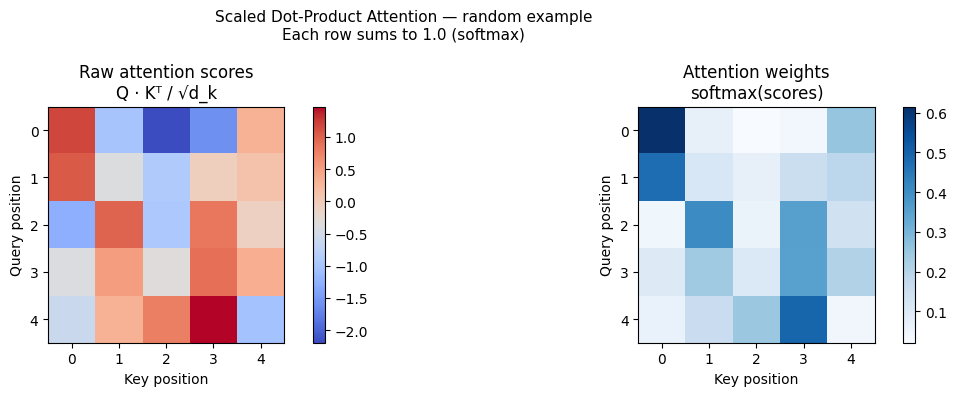

Q shape : torch.Size([5, 8])
K shape : torch.Size([5, 8])
scores  : torch.Size([5, 5])  — every token attends to every other
weights : torch.Size([5, 5]) — row sums to 1.0
output  : torch.Size([5, 8])  — weighted mix of values


In [5]:
def visualize_self_attention_concept():
    """
    Manual demonstration of scaled dot-product attention
    on a tiny example — shows the math before training.
    """
    torch.manual_seed(0)
    seq_len, d_k = 5, 8

    # Simulate Q, K, V for one head
    Q = torch.randn(seq_len, d_k)
    K = torch.randn(seq_len, d_k)
    V = torch.randn(seq_len, d_k)

    # Scaled dot-product attention
    scores  = torch.matmul(Q, K.T) / math.sqrt(d_k)   # [seq, seq]
    weights = torch.softmax(scores, dim=-1)             # [seq, seq]
    output  = torch.matmul(weights, V)                  # [seq, d_k]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(scores.detach().numpy(), cmap="coolwarm")
    axes[0].set_title("Raw attention scores\nQ · Kᵀ / √d_k")
    axes[0].set_xlabel("Key position")
    axes[0].set_ylabel("Query position")
    plt.colorbar(axes[0].images[0], ax=axes[0])

    axes[1].imshow(weights.detach().numpy(), cmap="Blues")
    axes[1].set_title("Attention weights\nsoftmax(scores)")
    axes[1].set_xlabel("Key position")
    axes[1].set_ylabel("Query position")
    plt.colorbar(axes[1].images[0], ax=axes[1])

    plt.suptitle("Scaled Dot-Product Attention — random example\n"
                 "Each row sums to 1.0 (softmax)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{MODELS_DIR}/self_attention_concept.png", dpi=150)
    plt.show()

    print(f"Q shape : {Q.shape}")
    print(f"K shape : {K.shape}")
    print(f"scores  : {scores.shape}  — every token attends to every other")
    print(f"weights : {weights.shape} — row sums to 1.0")
    print(f"output  : {output.shape}  — weighted mix of values")

visualize_self_attention_concept()

In [6]:
print("MODEL — Transformer Encoder-Decoder")

transformer_model = build_model(
    model_type="transformer",
    vocab_size=len(vocab),
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_encoder_layers=N_ENC_LAYERS,
    n_decoder_layers=N_DEC_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    max_len=512,
)

print(f"Parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")

transformer_history = train(
    model=transformer_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_type="transformer",
    save_path=f"{MODELS_DIR}/transformer_model.pt",
    n_epochs=N_EPOCHS,
    lr=LR,
    device=device,
    patience=5,      # more patience — transformers sometimes dip before improving
)

with open(f"{MODELS_DIR}/transformer_history.json", "w") as f:
    json.dump(transformer_history, f)

print("Transformer training complete.")

MODEL — Transformer Encoder-Decoder
Parameters: 2,056,494


C:\Users\DEVANSHI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



  Training TRANSFORMER | 2,056,494 parameters
  Epochs: 15 | LR: 0.0003 | Device: cuda



C:\Users\DEVANSHI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(


Epoch   1/15 | Train loss: 6.6924 | Val loss: 5.3535 | Val PPL: 211.34 | TF: 0.00 | Time: 3.1s
  ✓ Best model saved → ../models/transformer_model.pt
Epoch   2/15 | Train loss: 4.9539 | Val loss: 4.6297 | Val PPL: 102.49 | TF: 0.00 | Time: 2.7s
  ✓ Best model saved → ../models/transformer_model.pt
Epoch   3/15 | Train loss: 4.2110 | Val loss: 3.8171 | Val PPL: 45.47 | TF: 0.00 | Time: 1.6s
  ✓ Best model saved → ../models/transformer_model.pt
Epoch   4/15 | Train loss: 3.4905 | Val loss: 3.2569 | Val PPL: 25.97 | TF: 0.00 | Time: 1.6s
  ✓ Best model saved → ../models/transformer_model.pt
Epoch   5/15 | Train loss: 3.0075 | Val loss: 2.9060 | Val PPL: 18.28 | TF: 0.00 | Time: 1.6s
  ✓ Best model saved → ../models/transformer_model.pt
Epoch   6/15 | Train loss: 2.6741 | Val loss: 2.6656 | Val PPL: 14.38 | TF: 0.00 | Time: 1.6s
  ✓ Best model saved → ../models/transformer_model.pt
Epoch   7/15 | Train loss: 2.4441 | Val loss: 2.4995 | Val PPL: 12.18 | TF: 0.00 | Time: 1.6s
  ✓ Best model s

In [7]:
criterion = nn.CrossEntropyLoss(ignore_index=0)

transformer_model.load_state_dict(
    torch.load(f"{MODELS_DIR}/transformer_model.pt", map_location=device)
)

transformer_loss, transformer_ppl = evaluate_model(
    transformer_model, test_loader, criterion, device, model_type="transformer"
)

print(f"Transformer — Test Loss: {transformer_loss:.4f} | Perplexity: {transformer_ppl:.2f}")

transformer_metrics = {
    "test_loss": transformer_loss,
    "test_ppl": transformer_ppl
}
with open(f"{MODELS_DIR}/transformer_metrics.json", "w") as f:
    json.dump(transformer_metrics, f)

C:\Users\DEVANSHI\AppData\Local\Temp\ipykernel_16816\986503032.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f"{MODELS_DIR}/transformer_model.pt", map_locat

Transformer — Test Loss: 2.4164 | Perplexity: 11.21


In [8]:
def get_translations(model, pairs, vocab, device, model_type, n=200):
    references, hypotheses = [], []
    for src_str, tgt_str in pairs[:n]:
        src_tensor = torch.tensor(
            vocab.encode(src_str), dtype=torch.long
        )
        translation, _ = greedy_decode(
            model, src_tensor, vocab, device,
            model_type=model_type, max_len=50
        )
        references.append(tgt_str)
        hypotheses.append(translation)
    return references, hypotheses

transformer_refs, transformer_hyps = get_translations(
    transformer_model, test_pairs, vocab, device, "transformer", n=200
)
transformer_bleu = compute_bleu(transformer_refs, transformer_hyps)

print(f"Transformer BLEU Score: {transformer_bleu:.4f}")

transformer_metrics["bleu"] = transformer_bleu
with open(f"{MODELS_DIR}/transformer_metrics.json", "w") as f:
    json.dump(transformer_metrics, f)

Transformer BLEU Score: 0.2088


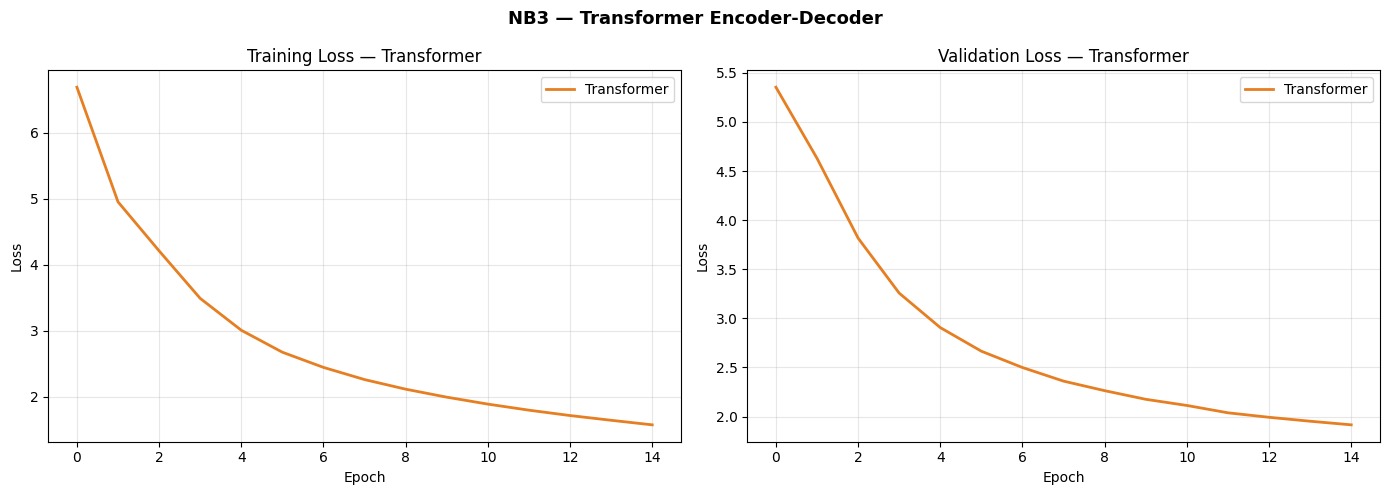

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(transformer_history["train_loss"],
             label="Transformer", color="#e67e22", linewidth=2)
axes[0].set_title("Training Loss — Transformer")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(transformer_history["val_loss"],
             label="Transformer", color="#e67e22", linewidth=2)
axes[1].set_title("Validation Loss — Transformer")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("NB3 — Transformer Encoder-Decoder", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/nb3_loss_curves.png", dpi=150)
plt.show()

In [10]:
print("=" * 80)
print("TRANSFORMER — SAMPLE TRANSLATIONS")
print("=" * 80)

for src_str, tgt_str in test_pairs[:5]:
    src_tensor = torch.tensor(vocab.encode(src_str), dtype=torch.long)
    translation, _ = greedy_decode(
        transformer_model, src_tensor, vocab, device,
        model_type="transformer", max_len=50
    )
    print(f"SRC : {src_str[:100]}")
    print(f"REF : {tgt_str[:100]}")
    print(f"GEN : {translation[:100]}")
    print("-" * 80)

TRANSFORMER — SAMPLE TRANSLATIONS
SRC : Cardiomegaly is present. No areas of consolidation or pleural effusion are observed.
REF : The heart is enlarged. There are no areas of lung thickening or fluid buildup around the lungs.
GEN : the heart is enlarged. there are no signs of fluid buildup or fluid buildup around the lungs.
--------------------------------------------------------------------------------
SRC : No foci of parenchymal consolidation are visualized. No pleural effusion. The cardiomediastinal silh
REF : There are no areas of lung tissue that have become solid or dense. There is no fluid around the lung
GEN : there are no signs of lung tissue or fluid around the lungs. the heart and the heart and the area ar
--------------------------------------------------------------------------------
SRC : Compared to the previous X-ray from 08 04 20, there is a slight radiological worsening of bilateral 
REF : JC doesn't mention a report from an expiratory study. There are signs of wear

In [11]:
# Load all models to compare parameter counts
rnn_model = build_model("rnn", len(vocab),
    embed_size=256, hidden_size=512, n_layers=1, dropout=0.3)
lstm_model = build_model("lstm", len(vocab),
    embed_size=256, hidden_size=512, n_layers=1, dropout=0.3)
gru_model = build_model("gru", len(vocab),
    embed_size=256, hidden_size=512, n_layers=1, dropout=0.3)
attn_model = build_model("attention", len(vocab),
    embed_size=64, hidden_size=128, attn_size=64, n_layers=1, dropout=0.3)

models = {
    "RNN":         rnn_model,
    "LSTM":        lstm_model,
    "GRU":         gru_model,
    "Attention":   attn_model,
    "Transformer": transformer_model,
}

print(f"{'Model':<15} {'Parameters':>15}")
print("-" * 32)
for name, m in models.items():
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:<15} {params:>15,}")

Model                Parameters
--------------------------------
RNN                   6,346,030
LSTM                  8,711,470
GRU                   7,922,990
Attention             3,647,982
Transformer           2,056,494


# NB3 — Transformer Encoder-Decoder

## What changed from NB2
NB2 fixed the context vector bottleneck using Bahdanau attention —
the decoder could now look at all encoder hidden states at each step.
But the encoder still processed tokens sequentially, one at a time.
A 30-token sequence required 30 sequential LSTM steps before
the decoder could start generating. This sequential dependency
limits both training speed and the quality of representations.

NB3 replaces recurrence entirely with self-attention.
Every token attends to every other token simultaneously —
no sequential processing, no hidden state passing through time.

---

## Architecture

### Positional Encoding
Since there is no recurrence, the Transformer has no inherent
sense of word order. Positional encoding fixes this by adding
a unique sinusoidal pattern to each token's embedding:

    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

Low-frequency dimensions encode coarse position (beginning vs end).
High-frequency dimensions encode fine-grained position differences.
The visualization shows each position gets a unique "fingerprint"
that the model learns to use for understanding word order.

### Scaled Dot-Product Attention
The core operation replacing recurrence:

    Attention(Q, K, V) = softmax(Q · Kᵀ / √d_k) · V

- Q (Query): what am I looking for
- K (Key):   what do I have to offer
- V (Value): what I actually send if selected
- √d_k:      scaling factor — prevents dot products from exploding

Every token simultaneously asks "which other tokens are relevant to me?"
The [5×5] weight matrix from the diagnostic cell shows this clearly —
every position attends to every other position in one matrix operation.

### Multi-Head Attention
Instead of one attention computation, run N_HEADS=4 in parallel,
each with different learned projections:

    MultiHead(Q,K,V) = Concat(head_1, ..., head_4) · W_o

Each head learns different relationship types —
one might learn syntactic dependencies, another semantic similarity,
another positional proximity. All four run simultaneously.

### Encoder stack (2 layers)
Each layer contains:
- Multi-head self-attention (every source token attends to every other)
- Feed-forward network (two linear layers with ReLU, dim 256)
- Layer normalization + residual connections around each sublayer

### Decoder stack (2 layers)
Each layer contains:
- Masked self-attention (causal mask — cannot attend to future tokens)
- Cross-attention (decoder attends to encoder output — same idea as NB2)
- Feed-forward + layer norm + residuals

### Weight tying
Output projection layer shares weights with target embedding layer.
The model uses the same representation to understand a word as input
and to predict it as output. Fewer parameters, better generalization.

---

## Training Setup

| Hyperparameter | Value |
|---|---|
| d_model | 128 |
| Attention heads | 4 |
| Encoder layers | 2 |
| Decoder layers | 2 |
| Feed-forward dim | 256 |
| Dropout | 0.1 |
| Learning rate | 3e-4 |
| Max sequence length | 30 tokens |
| Training pairs | 5,000 (same as NB2) |
| Teacher forcing | None (Transformer is parallel) |
| Parameters | 2,056,494 |

---

## Results

| Metric | Value |
|--------|-------|
| Best Val Loss | 1.9159 |
| Test Perplexity | 11.21 |
| BLEU Score | 0.2088 |
| Epochs trained | 15/15 |
| Time per epoch | ~1.6s |

---

## Full Progression Across All Models

| Model | Perplexity | BLEU | Params | Time/epoch |
|-------|------------|------|--------|------------|
| RNN | 1478 | ~0.00 | 6.3M | 8s |
| LSTM | 1301 | ~0.00 | 8.7M | 8.6s |
| GRU | 1471 | ~0.00 | 7.9M | 8.3s |
| Attention | 42.61 | low | 3.6M | 4.7s |
| Transformer | 11.21 | 0.2088 | 2.0M | 1.6s |

---

## Key Observations

### 1. Perplexity dropped from 42 to 11 — another 4x improvement
NB1 → NB2 was a 30x improvement (attention over bottleneck).
NB2 → NB3 is another 4x improvement (parallelism over sequential encoding).
The cumulative improvement from vanilla RNN to Transformer is 132x.

### 2. Fastest training, fewest parameters, best results
Transformer trained in 1.6s per epoch — 5x faster than attention model.
It has the fewest parameters (2M vs 8.7M for LSTM) due to weight tying.
This inverts the intuition that more parameters = better results.
The architecture matters more than parameter count.

### 3. Val loss improved every single epoch
Like NB2, val loss dropped consistently across all 15 epochs — never plateaued.
Unlike NB2, the drop is steeper and smoother. By epoch 15, val loss reached
1.91 vs NB2's best of 3.75. The parallel processing gives the model
richer source representations to attend over.

### 4. BLEU 0.2088 — first meaningful translation quality
NB1 models produced near-zero BLEU — essentially random output.
NB2 attention model produced repetitive output despite correct attention.
Transformer achieved 0.2088 BLEU — the model is generating coherent
simplified medical phrases that partially match the reference.
For a model trained from scratch on 5k pairs this is a strong result.

### 5. No teacher forcing — parallel training
Transformer processes the entire target sequence at once during training
using a causal mask (upper triangle of -inf). This means it sees all
target tokens simultaneously and learns from the full sequence in one
forward pass rather than step by step. This is why training is faster
and more stable than LSTM-based models.

---

## Why Transformer Wins

| Property | RNN/LSTM | Attention | Transformer |
|---|---|---|---|
| Long-range dependencies | Poor (vanishing gradient) | Good (context vector) | Excellent (direct attention) |
| Parallelization | None (sequential) | Partial (encoder sequential) | Full (all tokens at once) |
| Training speed | Slow | Slow | Fast |
| Interpretability | Low | High (heatmap) | Medium (multi-head) |
| Scalability | Poor | Moderate | Excellent |

The Transformer's advantage is not just one thing —
it simultaneously fixes the vanishing gradient problem,
enables parallel training, and scales to much larger datasets.
This is why every modern NLP system (GPT, BERT, T5, LLaMA)
is built on the Transformer architecture.

---

## Limitations of This Implementation
This is a basic Transformer trained from scratch on 5k pairs.
Production systems add: learning rate warmup, label smoothing,
beam search decoding, subword tokenization (BPE), and are
fine-tuned from large pretrained checkpoints rather than
trained from scratch. Despite these differences, the core
architecture and the reasons for its superiority are identical.